# SimGuard — Stage 2: Cohort Z-Score Adjustment

Tests whether normalising IsolationForest scores **within subscription tier**
improves recall for low-volume misuse categories (`ghost_usage`, `data_reselling`)
without hurting the categories that already work well.

| # | Cell | Purpose |
|---|------|---------|
| 1 | Imports & installs | pip, all library imports |
| 2 | Paths, seed, MLflow | SEED, dirs, tracking |
| 3 | Load data | 6 parquet splits |
| 4 | Load model | isolation\_forest.joblib |
| 5 | Reconstruct tier | one-hot → single tier column |
| 6 | Score (negated) | iso\_anomaly\_score |
| 7 | Cohort stats | per-tier median + IQR from train only |
| 8 | Apply normalization | cohort\_z\_* columns |
| 9 | Sanity checks | describe, NaN/inf, extreme values |
| 10 | Save v2 features | X\_\*\_v2.parquet (additive) |
| 11 | Save feature list | feature\_columns\_v2.json |
| 12 | Hypothesis test | threshold cohort\_z score → metrics |
| 13 | Before / after table | category comparison |
| 14 | Log to MLflow | cohort stats, metrics, end run |

> **Colab users:** upload `ml-service/` and `os.chdir('ml-service')` before running.
> Adjust `DATA_DIR` / `ARTIFACT_DIR` in Cell 2 if your upload layout differs.

## Cell 1 — Imports & Installs
All pip installs and library imports. Nothing else here.

In [1]:
# Cell 1: Imports & Installs
# Adjust DATA_DIR / ARTIFACT_DIR in Cell 2 if your Colab upload structure differs.

!pip install -q scikit-learn joblib pandas numpy mlflow pyarrow

import os, json, warnings
import numpy as np
import pandas as pd
import joblib
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score, precision_score, recall_score, average_precision_score,
)

warnings.filterwarnings('ignore', category=UserWarning)
print(' Imports complete.')


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Imports complete.


## Cell 2 — Seed, Paths & MLflow Setup
Set `SEED`, directory paths, and configure MLflow.
Uses the same SQLite backend as `isolation_forest.ipynb`.

In [9]:
# Cell 2: Seed, Paths & MLflow Setup

SEED = 42
np.random.seed(SEED)

#Paths
DATA_DIR     = 'data'
ARTIFACT_DIR = 'artifacts'

# Auto-detect if running from notebooks/ subdirectory 
if not os.path.isdir(DATA_DIR) and os.path.isdir(os.path.join('..', DATA_DIR)):
    os.chdir('..')
    print(f'  CWD adjusted to: {os.getcwd()}')

assert os.path.isdir(DATA_DIR), (
    f'DATA_DIR={DATA_DIR!r} not found from CWD={os.getcwd()!r}. '
    f'If running in Colab, run: import os; os.chdir("ml-service") first.'
)


#  MLflow (same experiment as isolation_forest.ipynb)
os.environ.setdefault('MLFLOW_ALLOW_FILE_STORE', 'true')
MLFLOW_DB = 'sqlite:///mlruns.db'
mlflow.set_tracking_uri(MLFLOW_DB)
mlflow.set_experiment('simguard-stage1-isolation-forest')

print(f'SEED         : {SEED}')
print(f'DATA_DIR     : {os.path.abspath(DATA_DIR)}')
print(f'ARTIFACT_DIR : {os.path.abspath(ARTIFACT_DIR)}')
print(f'MLflow URI   : {mlflow.get_tracking_uri()}')
print(f'MLflow exp   : simguard-stage1-isolation-forest')
print(' Setup complete.')

  CWD adjusted to: c:\Users\ADMIN\Desktop\projects\simguard\ml-service
SEED         : 42
DATA_DIR     : c:\Users\ADMIN\Desktop\projects\simguard\ml-service\data
ARTIFACT_DIR : c:\Users\ADMIN\Desktop\projects\simguard\ml-service\artifacts
MLflow URI   : sqlite:///mlruns.db
MLflow exp   : simguard-stage1-isolation-forest
 Setup complete.


## Cell 3 — Load Parquet Splits
Reads the six splits. X and y are kept in **separate DataFrames** and
will only be joined at the final evaluation step (Cell 12).

In [10]:
# Cell 3: Load Parquet Splits

X_train_raw = pd.read_parquet(os.path.join(DATA_DIR, 'X_train.parquet'))
X_val_raw   = pd.read_parquet(os.path.join(DATA_DIR, 'X_val.parquet'))
X_test_raw  = pd.read_parquet(os.path.join(DATA_DIR, 'X_test.parquet'))
y_train     = pd.read_parquet(os.path.join(DATA_DIR, 'y_train.parquet'))
y_val       = pd.read_parquet(os.path.join(DATA_DIR, 'y_val.parquet'))
y_test      = pd.read_parquet(os.path.join(DATA_DIR, 'y_test.parquet'))

print('Split shapes:')
for name, df in [('X_train_raw', X_train_raw), ('X_val_raw', X_val_raw),
                  ('X_test_raw', X_test_raw),  ('y_train', y_train),
                  ('y_val',      y_val),        ('y_test',  y_test)]:
    print(f'  {name:<12}: {df.shape}')

# Sanity: X and y must never be merged before evaluation
for col in ['is_anomalous', 'misuse_category']:
    assert col not in X_train_raw.columns, f'Label column {col!r} found in X_train!'
print('\n Data loaded. X and y are separate — will join only at Cell 12.')

Split shapes:
  X_train_raw : (63000, 44)
  X_val_raw   : (13500, 44)
  X_test_raw  : (13500, 44)
  y_train     : (63000, 4)
  y_val       : (13500, 4)
  y_test      : (13500, 4)

 Data loaded. X and y are separate — will join only at Cell 12.


## Cell 4 — Load IsolationForest Model
Loads the fitted model saved by `isolation_forest.ipynb`.
No re-fitting happens in this notebook.

In [11]:
# Cell 4: Load IsolationForest Model

MODEL_PATH = os.path.join(ARTIFACT_DIR, 'isolation_forest.joblib')
iso = joblib.load(MODEL_PATH)

print(f'Loaded model from : {MODEL_PATH}')
print(f'  Type            : {type(iso).__name__}')
print(f'  n_estimators    : {iso.n_estimators}')
print(f'  contamination   : {iso.contamination}')
print(f'  random_state    : {iso.random_state}')
print(' Model loaded.')

Loaded model from : artifacts\isolation_forest.joblib
  Type            : IsolationForest
  n_estimators    : 200
  contamination   : auto
  random_state    : 42
 Model loaded.


## Cell 5 — Reconstruct Tier Column
The tier was one-hot-encoded into `tier_field`, `tier_manager`,
`tier_professional`, `tier_support` during feature engineering.
This cell reverses that encoding back to a single `tier` string column,
which is required for the per-cohort groupby in Cell 7.

Prints the tier distribution per split as a sanity check.

In [12]:
# Cell 5: Reconstruct Tier Column

TIER_COLS = ['tier_field', 'tier_manager', 'tier_professional', 'tier_support']

def reconstruct_tier(df):
    present = [c for c in TIER_COLS if c in df.columns]
    assert len(present) > 0, f'No tier_* columns found in DataFrame!'
    # idxmax returns the column name with the highest value (1 in a one-hot)
    tier_col = df[present].idxmax(axis=1).str.replace('tier_', '', regex=False)
    return tier_col

# Apply to each split
tier_train = reconstruct_tier(X_train_raw)
tier_val   = reconstruct_tier(X_val_raw)
tier_test  = reconstruct_tier(X_test_raw)

print('Tier distribution per split:')
for name, t in [('Train', tier_train), ('Val', tier_val), ('Test', tier_test)]:
    counts = t.value_counts().sort_index()
    print(f'\n  {name}:')
    for tier, n in counts.items():
        print(f'    {tier:<15}: {n:>7,}  ({n/len(t)*100:.1f}%)')

print('\n Tier column reconstructed for all splits.')

Tier distribution per split:

  Train:
    field          :   4,140  (6.6%)
    manager        :  20,340  (32.3%)
    professional   :  28,620  (45.4%)
    support        :   9,900  (15.7%)

  Val:
    field          :     720  (5.3%)
    manager        :   4,860  (36.0%)
    professional   :   6,390  (47.3%)
    support        :   1,530  (11.3%)

  Test:
    field          :     810  (6.0%)
    manager        :   4,410  (32.7%)
    professional   :   6,210  (46.0%)
    support        :   2,070  (15.3%)

 Tier column reconstructed for all splits.


## Cell 6 — Score With IsolationForest (Negated)

Applies the loaded IsolationForest's `decision_function` to all three splits
and **negates** the output so that **higher score = more anomalous**.

> **Sign-convention note:** `IsolationForest.decision_function` returns higher
> values for *normal* points (lower anomaly score). This is the opposite of
> what every downstream metric function expects. This project has hit this bug
> twice already — the PR curve and permutation importance in
> `isolation_forest.ipynb` both required the same flip. The negated score is
> stored as `iso_anomaly_score` so the correct sign is unambiguous for every
> notebook that reads these features.

The `sim_id` and `date` columns are dropped before scoring (model was trained
without them) and re-attached afterwards.

In [13]:
# Cell 6: Score With IsolationForest (Negated)

KEY_COLS = ['sim_id', 'date']

def score_split(df_raw, name):
    present_keys = [c for c in KEY_COLS if c in df_raw.columns]
    X = df_raw.drop(columns=present_keys)
    raw_score     = iso.decision_function(X)   # higher = more NORMAL
    neg_score     = -raw_score                 # higher = more ANOMALOUS
    out = df_raw[present_keys].copy() if present_keys else pd.DataFrame(index=df_raw.index)
    out['iso_anomaly_score'] = neg_score
    print(f'  [{name}] scored {len(df_raw):,} rows  |  '
          f'iso_anomaly_score  mean={neg_score.mean():.4f}  '
          f'min={neg_score.min():.4f}  max={neg_score.max():.4f}')
    return neg_score

print('Scoring splits (iso_anomaly_score = -decision_function):')
iso_score_train = score_split(X_train_raw, 'Train')
iso_score_val   = score_split(X_val_raw,   'Val')
iso_score_test  = score_split(X_test_raw,  'Test')

print('\n Scores computed. Higher iso_anomaly_score = more anomalous.')

Scoring splits (iso_anomaly_score = -decision_function):
  [Train] scored 63,000 rows  |  iso_anomaly_score  mean=-0.0822  min=-0.1499  max=0.1605
  [Val] scored 13,500 rows  |  iso_anomaly_score  mean=-0.0803  min=-0.1485  max=0.1684
  [Test] scored 13,500 rows  |  iso_anomaly_score  mean=-0.0806  min=-0.1491  max=0.1756

 Scores computed. Higher iso_anomaly_score = more anomalous.


## Cell 7 — Compute Cohort Statistics (Train Only)

For each of the four source columns, computes the **per-tier median** and
**IQR** (75th − 25th percentile) using **X_train rows only**.

These statistics are the cohort baselines — they will be applied to all three
splits in Cell 8, exactly like a scaler that is fit on train and applied to all.
Prints the full table so the baselines are visible.

In [14]:
# Cell 7: Compute Cohort Statistics (Train Only)

# Source columns for cohort normalisation
SOURCE_COLS = ['iso_anomaly_score', 'total_mb', 'vol_zscore_7d', 'vol_zscore_14d']

# Build a working frame for train: keys + tier + source cols + scores
train_work = X_train_raw.copy()
train_work['tier']             = tier_train.values
train_work['iso_anomaly_score'] = iso_score_train

val_work  = X_val_raw.copy()
val_work['tier']              = tier_val.values
val_work['iso_anomaly_score'] = iso_score_val

test_work = X_test_raw.copy()
test_work['tier']             = tier_test.values
test_work['iso_anomaly_score'] = iso_score_test

# Compute cohort stats FROM TRAIN ONLY
cohort_stats = {}   # {col: DataFrame(tier > {median, iqr})}

print('Cohort statistics (TRAIN only):')
print(f'  {"": <20}', end='')
for col in SOURCE_COLS:
    print(f'  {col[:18]:<18}', end='')
print()

tiers = sorted(train_work['tier'].unique())

for col in SOURCE_COLS:
    grp = train_work.groupby('tier')[col]
    med = grp.median()
    q75 = grp.quantile(0.75)
    q25 = grp.quantile(0.25)
    iqr = q75 - q25
    cohort_stats[col] = pd.DataFrame({'median': med, 'iqr': iqr})

print()
print(f'  {"Tier":<14}  {"Column":<22}  {"Median":>10}  {"IQR":>10}')
print(f'  {"-"*62}')
for tier in tiers:
    for col in SOURCE_COLS:
        m = cohort_stats[col].loc[tier, 'median']
        q = cohort_stats[col].loc[tier, 'iqr']
        print(f'  {tier:<14}  {col:<22}  {m:>10.4f}  {q:>10.4f}')
    print()

# Sanity: confirm stats came from train rows only
print(f'Stats derived from {len(train_work):,} train rows. '
      f'Val ({len(val_work):,}) and Test ({len(test_work):,}) rows were NOT used.')
print(' Cohort statistics computed from X_train only.')

Cohort statistics (TRAIN only):
                        iso_anomaly_score   total_mb            vol_zscore_7d       vol_zscore_14d    

  Tier            Column                      Median         IQR
  --------------------------------------------------------------
  field           iso_anomaly_score          -0.0151      0.0708
  field           total_mb                    1.0444      1.9162
  field           vol_zscore_7d               0.1622      1.7758
  field           vol_zscore_14d              0.1451      1.8067

  manager         iso_anomaly_score          -0.0843      0.0482
  manager         total_mb                    0.4306      1.0825
  manager         vol_zscore_7d               0.1489      1.7471
  manager         vol_zscore_14d              0.1491      1.7640

  professional    iso_anomaly_score          -0.1072      0.0400
  professional    total_mb                   -0.0671      0.7374
  professional    vol_zscore_7d               0.1485      1.7599
  professional   

## Cell 7b: Save Cohort Statistics for Reuse
Saves the train-only per-tier median and IQR to `artifacts/cohort_stats.json` so later stages can apply the same cohort normalisation to new data. The IQR values are the raw IQRs. Apply the 0.05 floor when using them: `(x - median) / max(iqr, 0.05)`.

In [15]:
# Cell 7b: Save Cohort Statistics for Reuse

import json
cohort_stats_export = {
    col: {
        'median': cohort_stats[col]['median'].to_dict(),
        'iqr': cohort_stats[col]['iqr'].to_dict(),
    }
    for col in SOURCE_COLS
}
with open(f"{ARTIFACT_DIR}/cohort_stats.json", "w") as f:
    json.dump(cohort_stats_export, f, indent=2)
print("Saved cohort_stats.json:")
print(json.dumps(cohort_stats_export, indent=2))

Saved cohort_stats.json:
{
  "iso_anomaly_score": {
    "median": {
      "field": -0.015105428604707427,
      "manager": -0.08427765899940234,
      "professional": -0.10715418073211677,
      "support": -0.08117190770554614
    },
    "iqr": {
      "field": 0.07081781303881451,
      "manager": 0.048185514733794635,
      "professional": 0.040044049713403806,
      "support": 0.03765923166365778
    }
  },
  "total_mb": {
    "median": {
      "field": 1.0443763536212405,
      "manager": 0.4305896162853332,
      "professional": -0.06708359870353518,
      "support": -0.5608480750535286
    },
    "iqr": {
      "field": 1.9162416920060137,
      "manager": 1.0824914162709243,
      "professional": 0.7373581938245407,
      "support": 0.3201715191716647
    }
  },
  "vol_zscore_7d": {
    "median": {
      "field": 0.162212494433088,
      "manager": 0.14888755411348642,
      "professional": 0.14850260982072205,
      "support": 0.13627710853838076
    },
    "iqr": {
      "fiel

## Cell 8 — Apply Cohort Normalisation

Applies the TRAIN-derived cohort statistics to all three splits:

```
cohort_z_X = (X - cohort_median[tier]) / max(cohort_iqr[tier], 0.05)
```

The **0.05 IQR floor** prevents divide-by-near-zero blowup — the same issue
that was seen with `vol_zscore_14d` earlier in this project.

Adds four new columns (`cohort_z_iso_anomaly_score`, `cohort_z_total_mb`,
`cohort_z_vol_zscore_7d`, `cohort_z_vol_zscore_14d`) to each working frame.
The original columns are left untouched.

In [16]:
# Cell 8: Apply Cohort Normalisation

IQR_FLOOR = 0.05   # prevents divide-by-near-zero

def apply_cohort_z(work_df, split_name):
    df = work_df.copy()
    for col in SOURCE_COLS:
        new_col = f'cohort_z_{col}'
        med_map = cohort_stats[col]['median']
        iqr_map = cohort_stats[col]['iqr'].clip(lower=IQR_FLOOR)
        tier_col = df['tier']
        med_vals = tier_col.map(med_map)
        iqr_vals = tier_col.map(iqr_map)
        df[new_col] = (df[col] - med_vals) / iqr_vals
    print(f'  [{split_name}] Added cohort_z_* columns. Shape: {df.shape}')
    return df

print('Applying cohort normalisation (stats from train, applied to all splits):')
train_work = apply_cohort_z(train_work, 'Train')
val_work   = apply_cohort_z(val_work,   'Val')
test_work  = apply_cohort_z(test_work,  'Test')

COHORT_Z_COLS = [f'cohort_z_{c}' for c in SOURCE_COLS]
print(f'\nNew columns: {COHORT_Z_COLS}')
print(' Cohort normalisation applied to all three splits.')

Applying cohort normalisation (stats from train, applied to all splits):
  [Train] Added cohort_z_* columns. Shape: (63000, 50)
  [Val] Added cohort_z_* columns. Shape: (13500, 50)
  [Test] Added cohort_z_* columns. Shape: (13500, 50)

New columns: ['cohort_z_iso_anomaly_score', 'cohort_z_total_mb', 'cohort_z_vol_zscore_7d', 'cohort_z_vol_zscore_14d']
 Cohort normalisation applied to all three splits.


## Cell 9 — Sanity Checks

Runs three explicit checks:
1. **Describe** the four new `cohort_z_*` columns on X_train.
2. **NaN / Inf check** across all three splits.
3. **Extreme-value flag**: any absolute value > 100 is printed.
   An IQR floor of 0.05 should prevent blowup, but this confirms it.

In [17]:
# Cell 9: Sanity Checks

# 1. Describe on train
print('=== describe() for cohort_z_* columns on X_train ===')
desc = train_work[COHORT_Z_COLS].describe().round(4)
print(desc.to_string())

# 2. NaN / Inf check across all splits
print('\n=== NaN / Inf check ===')
all_clean = True
for split_name, work_df in [('Train', train_work), ('Val', val_work), ('Test', test_work)]:
    for col in COHORT_Z_COLS:
        n_nan = work_df[col].isna().sum()
        n_inf = np.isinf(work_df[col]).sum()
        if n_nan > 0 or n_inf > 0:
            print(f'   [{split_name}] {col}: {n_nan} NaN, {n_inf} Inf')
            all_clean = False
if all_clean:
    print('   No NaN or Inf in any cohort_z_* column across all splits.')

# 3. Extreme-value check (|value| > 100)
print('\n=== Extreme-value check (|value| > 100) ===')
found_extreme = False
for split_name, work_df in [('Train', train_work), ('Val', val_work), ('Test', test_work)]:
    for col in COHORT_Z_COLS:
        extreme = (work_df[col].abs() > 100).sum()
        if extreme > 0:
            print(f'  [{split_name}] {col}: {extreme:,} values with |z| > 100')
            found_extreme = True
if not found_extreme:
    print('   No extreme values (|z| > 100) found — IQR floor is working.')

# 4. Confirm label columns never appeared in any work frame
print('\n=== Label-column contamination check ===')
for split_name, work_df in [('Train', train_work), ('Val', val_work), ('Test', test_work)]:
    for lc in ['is_anomalous', 'misuse_category']:
        assert lc not in work_df.columns, f'LEAK: {lc!r} in {split_name}!'
print('   is_anomalous and misuse_category are absent from all work frames.')

print('\nAll sanity checks passed.')

=== describe() for cohort_z_* columns on X_train ===
       cohort_z_iso_anomaly_score  cohort_z_total_mb  cohort_z_vol_zscore_7d  cohort_z_vol_zscore_14d
count                  63000.0000         63000.0000              63000.0000               63000.0000
mean                       0.1451             0.1472                 -0.0200                  -0.0289
std                        0.7021             0.8841                  3.5392                   3.4912
min                       -1.2525            -1.5460                -28.7991                 -28.4290
25%                       -0.3623            -0.4504                 -0.6537                  -0.6585
50%                        0.0000             0.0000                  0.0000                  -0.0000
75%                        0.4904             0.5472                  0.3451                   0.3416
max                        5.3524            23.8665                 28.6426                  28.2706

=== NaN / Inf check ===
   N

## Cell 10 — Save Enriched Feature Files

Saves the enriched DataFrames as `X_train_v2.parquet`, `X_val_v2.parquet`,
`X_test_v2.parquet`. These include all original columns **plus** the 4 new
`cohort_z_*` columns.

The original `X_train/val/test.parquet` files are **not overwritten**.
The `tier` and `iso_anomaly_score` working columns are **excluded** from the
saved files (they are intermediate artefacts, not final features).

In [18]:
# Cell 10: Save Enriched Feature Files

# Columns to exclude from saved v2 files (intermediate working columns)
EXCLUDE_COLS = ['tier', 'iso_anomaly_score']

def save_v2(work_df, original_raw, split_name, fname):
    # Start from original columns (preserves column order)
    orig_cols = list(original_raw.columns)
    new_cols  = [c for c in COHORT_Z_COLS if c in work_df.columns]
    save_cols = orig_cols + new_cols
    # Ensure no label columns slipped in
    for lc in ['is_anomalous', 'misuse_category']:
        assert lc not in save_cols, f'LEAK: {lc!r} would be saved to {fname}!'
    out_df = work_df[save_cols].reset_index(drop=True)
    path   = os.path.join(DATA_DIR, fname)
    out_df.to_parquet(path, index=False)
    print(f'  Saved {fname}: {out_df.shape}  →  {path}')
    return out_df

print('Saving enriched v2 feature files:')
X_train_v2 = save_v2(train_work, X_train_raw, 'Train', 'X_train_v2.parquet')
X_val_v2   = save_v2(val_work,   X_val_raw,   'Val',   'X_val_v2.parquet')
X_test_v2  = save_v2(test_work,  X_test_raw,  'Test',  'X_test_v2.parquet')

# Verify originals untouched
orig_reload = pd.read_parquet(os.path.join(DATA_DIR, 'X_train.parquet'))
assert list(orig_reload.columns) == list(X_train_raw.columns), \
    'Original X_train.parquet was modified!'
print('\n   Original X_train.parquet is unchanged.')
print(' v2 files saved.')

Saving enriched v2 feature files:
  Saved X_train_v2.parquet: (63000, 48)  →  data\X_train_v2.parquet
  Saved X_val_v2.parquet: (13500, 48)  →  data\X_val_v2.parquet
  Saved X_test_v2.parquet: (13500, 48)  →  data\X_test_v2.parquet

   Original X_train.parquet is unchanged.
 v2 files saved.


## Cell 11 — Save Feature Column List (v2)

Saves `artifacts/feature_columns_v2.json` with the full updated feature list:
all original features **plus** the 4 new `cohort_z_*` columns.
This file is the v2 equivalent of `feature_columns.json` and should be used
by any downstream notebook that loads `X_*_v2.parquet`.

In [19]:
# Cell 11: Save Feature Column List (v2)

# Load original feature list
with open(os.path.join(ARTIFACT_DIR, 'feature_columns.json')) as f:
    v1_meta = json.load(f)

v1_features = v1_meta['features']
v2_features = v1_features + COHORT_Z_COLS

v2_meta = {
    'version':       2,
    'description':   'Original v1 features + 4 cohort-normalised z-score columns',
    'features':      v2_features,
    'new_features':  COHORT_Z_COLS,
    'source_cols':   SOURCE_COLS,
    'iqr_floor':     0.05,
    'cohort_column': 'tier',
}

v2_path = os.path.join(ARTIFACT_DIR, 'feature_columns_v2.json')
with open(v2_path, 'w') as f:
    json.dump(v2_meta, f, indent=2)

print(f'Saved: {v2_path}')
print(f'v1 features : {len(v1_features)}')
print(f'New features: {COHORT_Z_COLS}')
print(f'v2 total    : {len(v2_features)}')
print(' feature_columns_v2.json saved.')

Saved: artifacts\feature_columns_v2.json
v1 features : 42
New features: ['cohort_z_iso_anomaly_score', 'cohort_z_total_mb', 'cohort_z_vol_zscore_7d', 'cohort_z_vol_zscore_14d']
v2 total    : 46
 feature_columns_v2.json saved.


## Cell 12 — Hypothesis Test

Tests whether thresholding `cohort_z_iso_anomaly_score` on the val set
yields better per-category recall than the original IsolationForest `predict()`.

**Threshold choice:** the percentile of `cohort_z_iso_anomaly_score` on the
val set that gives the same overall flagged fraction as the original model
(≈ 6.31% on val). This ensures a fair comparison — same number of anomaly
flags, different which rows get flagged.

Precision is computed against the **full** val set (same fix as in
`isolation_forest.ipynb` Cell 11) — not a category-pre-filtered subset.

In [20]:
# Cell 12: Hypothesis Test

# ── Baseline (original IsoForest predict) ────────────────────────────────
# Reconstruct val_preds from the loaded model for a fair comparison
KEY_COLS_PRESENT = [c for c in ['sim_id', 'date'] if c in X_val_raw.columns]
X_val_feat = X_val_raw.drop(columns=KEY_COLS_PRESENT)
val_preds_orig = iso.predict(X_val_feat)   # -1 = anomaly, +1 = inlier

orig_flag_rate = (val_preds_orig == -1).mean()
print(f'Original model flagged fraction (val): {orig_flag_rate*100:.2f}%')

# ── Cohort-adjusted threshold ─────────────────────────────────────────────
# Use the percentile on val that matches the original flag rate
cohort_z_val = val_work['cohort_z_iso_anomaly_score'].values
threshold    = np.percentile(cohort_z_val, (1 - orig_flag_rate) * 100)
val_preds_cohort = (cohort_z_val >= threshold).astype(int)  # 1 = anomaly
cohort_flag_rate = val_preds_cohort.mean()
print(f'Cohort threshold              : {threshold:.4f}')
print(f'Cohort-adjusted flag fraction : {cohort_flag_rate*100:.2f}%')

# ── Join to labels ────────────────────────────────────────────────────────
eval_df = y_val.copy()
# Attach original pred flags (-1/+1 → 1/0)
eval_df['orig_flag']   = (val_preds_orig == -1).astype(int)
eval_df['cohort_flag'] = val_preds_cohort

# Check row alignment (X_val_raw and y_val must share the same sim_id+date order)
if KEY_COLS_PRESENT:
    val_keys = X_val_raw[KEY_COLS_PRESENT].reset_index(drop=True)
    y_val_k  = y_val[KEY_COLS_PRESENT].reset_index(drop=True)
    assert val_keys.equals(y_val_k), 'X_val and y_val sim_id/date order mismatch!'
print('\n X_val and y_val row alignment confirmed.')

# ── Per-category metrics helper (same logic as isolation_forest.ipynb Cell 11) ─
MISUSE_CATS = ['ghost_usage', 'unauthorized_sharing',
               'data_reselling', 'inactive_billing', 'normal']

def per_cat_metrics(eval_df, flag_col):
    pred_anom = eval_df[flag_col] == 1
    results   = {}
    for cat in MISUSE_CATS:
        if cat == 'normal':
            pos_mask = eval_df['is_anomalous'] == 0
            n        = int(pos_mask.sum())
            if n == 0:
                continue
            pred_pos = eval_df[flag_col] == 0
            tp  = int((pred_pos & pos_mask).sum())
            fp  = int((pred_pos & ~pos_mask).sum())
            rec = tp / n
            pre = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        else:
            cat_mask = eval_df['misuse_category'] == cat
            n        = int(cat_mask.sum())
            if n == 0:
                continue
            tp_rec = int((pred_anom & cat_mask).sum())
            tp_pre = tp_rec
            fp_pre = int((pred_anom & ~cat_mask).sum())
            rec = tp_rec / n
            pre = tp_pre / (tp_pre + fp_pre) if (tp_pre + fp_pre) > 0 else 0.0
        f1 = 2 * pre * rec / (pre + rec) if (pre + rec) > 0 else 0.0
        results[cat] = {'n': n, 'precision': pre, 'recall': rec, 'f1': f1}
    return results

orig_metrics   = per_cat_metrics(eval_df, 'orig_flag')
cohort_metrics = per_cat_metrics(eval_df, 'cohort_flag')

print('\n Hypothesis test metrics computed.')

Original model flagged fraction (val): 6.31%
Cohort threshold              : 1.6049
Cohort-adjusted flag fraction : 6.31%

 X_val and y_val row alignment confirmed.

 Hypothesis test metrics computed.


## Cell 13 — Before / After Comparison Table

Side-by-side comparison of per-category precision and recall:
**original IsolationForest** vs **cohort-z-score-adjusted threshold**.

Known baseline from `isolation_forest.ipynb` (val set):
- `ghost_usage` recall: **0.1667**
- `data_reselling` recall: **0.3663**
- `unauthorized_sharing` recall: **0.8295**
- `inactive_billing` recall: **0.8571**

States plainly whether each category improved, stayed flat, or got worse.

Reference baseline check (isolation_forest.ipynb):
  ghost_usage              recall=0.1667  prec=0.0293   match
  unauthorized_sharing     recall=0.8295  prec=0.2113   match
  data_reselling           recall=0.3663  prec=0.0434   match
  inactive_billing         recall=0.8571  prec=0.0563   match


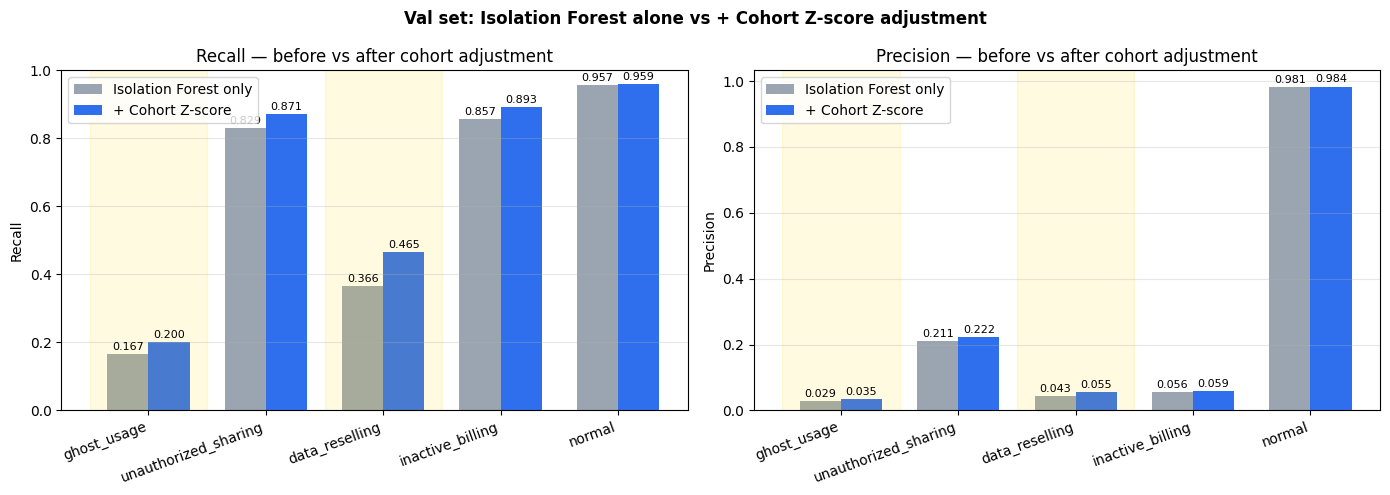


PLAIN-LANGUAGE VERDICT
  ghost_usage             : recall IMPROVED (+0.0333)
  data_reselling          : recall IMPROVED (+0.0990)

  unauthorized_sharing    : recall ALSO improved (+0.0415)
  inactive_billing        : recall ALSO improved (+0.0357)


In [21]:
# Cell 13: Before / After Comparison — Plot

# Known baselines from isolation_forest.ipynb (val set)
KNOWN_BASELINE = {
    'ghost_usage':          {'recall': 0.1667, 'precision': 0.0293},
    'unauthorized_sharing': {'recall': 0.8295, 'precision': 0.2113},
    'data_reselling':       {'recall': 0.3663, 'precision': 0.0434},
    'inactive_billing':     {'recall': 0.8571, 'precision': 0.0563},
}

FOCUS_CATS  = ['ghost_usage', 'data_reselling']
STABLE_CATS = ['unauthorized_sharing', 'inactive_billing']
summary = {}

for cat in MISUSE_CATS:
    if cat not in orig_metrics:
        continue
    summary[cat] = {
        'old_recall':    orig_metrics[cat]['recall'],
        'new_recall':    cohort_metrics.get(cat, {}).get('recall', float('nan')),
        'old_precision': orig_metrics[cat]['precision'],
        'new_precision': cohort_metrics.get(cat, {}).get('precision', float('nan')),
    }

# print the baseline match check (kept as text, it's a one-line integrity
# check, not something that benefits from a chart)
print('Reference baseline check (isolation_forest.ipynb):')
for cat, vals in KNOWN_BASELINE.items():
    ok = abs(orig_metrics.get(cat, {}).get('recall', 0) - vals['recall']) < 0.02
    print(f'  {cat:<24} recall={vals["recall"]:.4f}  prec={vals["precision"]:.4f}  ',
          'match' if ok else 'MISMATCH vs known baseline')

cats = list(summary.keys())
x = np.arange(len(cats))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Recall subplot ---
ax = axes[0]
old_r = [summary[c]['old_recall'] for c in cats]
new_r = [summary[c]['new_recall'] for c in cats]
bars_old = ax.bar(x - width/2, old_r, width, label='Isolation Forest only', color='#9aa5b1')
bars_new = ax.bar(x + width/2, new_r, width, label='+ Cohort Z-score', color='#2f6fed')
ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=20, ha='right')
ax.set_ylabel('Recall')
ax.set_title('Recall — before vs after cohort adjustment')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars, vals in [(bars_old, old_r), (bars_new, new_r)]:
    for b, v in zip(bars, vals):
        ax.annotate(f'{v:.3f}', (b.get_x() + b.get_width()/2, v),
                    textcoords="offset points", xytext=(0, 3), ha='center', fontsize=8)

# highlight the two focus categories
for i, c in enumerate(cats):
    if c in FOCUS_CATS:
        ax.axvspan(i - 0.5, i + 0.5, color='gold', alpha=0.12)

# --- Precision subplot ---
ax = axes[1]
old_p = [summary[c]['old_precision'] for c in cats]
new_p = [summary[c]['new_precision'] for c in cats]
bars_old = ax.bar(x - width/2, old_p, width, label='Isolation Forest only', color='#9aa5b1')
bars_new = ax.bar(x + width/2, new_p, width, label='+ Cohort Z-score', color='#2f6fed')
ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=20, ha='right')
ax.set_ylabel('Precision')
ax.set_title('Precision — before vs after cohort adjustment')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars, vals in [(bars_old, old_p), (bars_new, new_p)]:
    for b, v in zip(bars, vals):
        ax.annotate(f'{v:.3f}', (b.get_x() + b.get_width()/2, v),
                    textcoords="offset points", xytext=(0, 3), ha='center', fontsize=8)

for i, c in enumerate(cats):
    if c in FOCUS_CATS:
        ax.axvspan(i - 0.5, i + 0.5, color='gold', alpha=0.12)

fig.suptitle('Val set: Isolation Forest alone vs + Cohort Z-score adjustment', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/cohort_before_after.png", dpi=150, bbox_inches='tight')
plt.show()

mlflow.log_artifact(f"{ARTIFACT_DIR}/cohort_before_after.png")

# plain-language verdict, kept as print since this is a conclusion to
# read, not data to visualize
print()
print('PLAIN-LANGUAGE VERDICT')
for cat in FOCUS_CATS:
    if cat in summary:
        d = summary[cat]['new_recall'] - summary[cat]['old_recall']
        tag = 'IMPROVED' if d > 0.005 else ('GOT WORSE' if d < -0.005 else 'FLAT')
        print(f'  {cat:<24}: recall {tag} ({d:+.4f})')
print()
for cat in STABLE_CATS:
    if cat in summary:
        d = summary[cat]['new_recall'] - summary[cat]['old_recall']
        tag = 'HURT' if d < -0.02 else ('ALSO improved' if d > 0.02 else 'STABLE')
        print(f'  {cat:<24}: recall {tag} ({d:+.4f})')

## Cell 14 — Log to MLflow & End Run

Logs cohort statistics, before/after metrics, and all comparison data to a
new MLflow run in the same `simguard-stage1-isolation-forest` experiment.
Ends the run cleanly.

In [22]:
# Cell 14: Log to MLflow & End Run

# Close any stale run
if mlflow.active_run() is not None:
    print(f'   Closing stale run: {mlflow.active_run().info.run_id}')
    mlflow.end_run()

with mlflow.start_run(run_name='cohort-zscore-adjustment') as run:
    RUN_ID = run.info.run_id
    print(f'MLflow run: {RUN_ID}')

    # Log cohort stats
    mlflow.log_param('iqr_floor',         0.05)
    mlflow.log_param('cohort_column',     'tier')
    mlflow.log_param('source_cols',       str(SOURCE_COLS))
    mlflow.log_param('threshold_pct',     f'{(1 - orig_flag_rate)*100:.1f}th percentile')
    mlflow.log_param('cohort_flag_rate',  round(float(cohort_flag_rate), 4))
    mlflow.log_param('orig_flag_rate',    round(float(orig_flag_rate),   4))

    # Log per-tier cohort stats as params
    for col in SOURCE_COLS:
        for tier in tiers:
            m = cohort_stats[col].loc[tier, 'median']
            q = cohort_stats[col].loc[tier, 'iqr']
            safe = col.replace(' ', '_')[:20]
            mlflow.log_param(f'med_{safe}_{tier}', round(float(m), 4))
            mlflow.log_param(f'iqr_{safe}_{tier}', round(float(q), 4))

    #  Log before/after metrics
    for cat in MISUSE_CATS:
        if cat not in orig_metrics:
            continue
        safe = cat.replace(' ', '_')
        mlflow.log_metric(f'orig_recall_{safe}',    orig_metrics[cat]['recall'])
        mlflow.log_metric(f'orig_precision_{safe}', orig_metrics[cat]['precision'])
        mlflow.log_metric(f'orig_f1_{safe}',        orig_metrics[cat]['f1'])
        if cat in cohort_metrics:
            mlflow.log_metric(f'cohort_recall_{safe}',    cohort_metrics[cat]['recall'])
            mlflow.log_metric(f'cohort_precision_{safe}', cohort_metrics[cat]['precision'])
            mlflow.log_metric(f'cohort_f1_{safe}',        cohort_metrics[cat]['f1'])
            mlflow.log_metric(f'delta_recall_{safe}',
                              cohort_metrics[cat]['recall'] - orig_metrics[cat]['recall'])

    #  Log feature_columns_v2.json as artifact
    mlflow.log_artifact(os.path.join(ARTIFACT_DIR, 'feature_columns_v2.json'))

    #  Final summary
    print(f'\n{"="*68}')
    print(f'  RUN COMPLETE')
    print(f'  Run ID       : {RUN_ID}')
    print(f'  MLflow DB    : {MLFLOW_DB}')
    print(f'  v2 files     : X_train_v2.parquet, X_val_v2.parquet, X_test_v2.parquet')
    print(f'  Artifact     : feature_columns_v2.json')
    print(f'{"="*68}')

print('\n MLflow run closed. cohort_zscore.ipynb complete.')

   Closing stale run: 566100d04b0d4663a12a8f6a235bfb63
MLflow run: 4f1ef8549e404f9792c56e78d677e3f8

  RUN COMPLETE
  Run ID       : 4f1ef8549e404f9792c56e78d677e3f8
  MLflow DB    : sqlite:///mlruns.db
  v2 files     : X_train_v2.parquet, X_val_v2.parquet, X_test_v2.parquet
  Artifact     : feature_columns_v2.json

 MLflow run closed. cohort_zscore.ipynb complete.


In [23]:
# Cell 15: Test-set confirmation

# 1. Score the test set (original model predictions)
KEY_COLS_PRESENT = [c for c in ['sim_id', 'date'] if c in X_test_raw.columns]
X_test_feat = X_test_raw.drop(columns=KEY_COLS_PRESENT)
test_preds_orig = iso.predict(X_test_feat)   # -1 = anomaly, +1 = inlier

# 2. Score with cohort z-score adjustment
cohort_z_test = test_work['cohort_z_iso_anomaly_score'].values
# Re-use the same threshold derived from the validation set
test_preds_cohort = (cohort_z_test >= threshold).astype(int)

# 3. Create merged test evaluation frames
test_eval_df = y_test.copy()
test_eval_df['orig_flag'] = (test_preds_orig == -1).astype(int)
test_eval_df['cohort_flag'] = test_preds_cohort

# Sanity check row alignment
if KEY_COLS_PRESENT:
    test_keys = X_test_raw[KEY_COLS_PRESENT].reset_index(drop=True)
    y_test_k = y_test[KEY_COLS_PRESENT].reset_index(drop=True)
    assert test_keys.equals(y_test_k), 'X_test and y_test alignment mismatch!'

# 4. Compute metrics using the correct helper function
old_test_metrics = per_cat_metrics(test_eval_df, 'orig_flag')
new_test_metrics = per_cat_metrics(test_eval_df, 'cohort_flag')

# 5. Output comparison
print("TEST SET \u2014 ghost_usage recall:",
      f"{old_test_metrics['ghost_usage']['recall']:.4f} -> {new_test_metrics['ghost_usage']['recall']:.4f}")
print("TEST SET \u2014 data_reselling recall:",
      f"{old_test_metrics['data_reselling']['recall']:.4f} -> {new_test_metrics['data_reselling']['recall']:.4f}")

TEST SET — ghost_usage recall: 0.2125 -> 0.1375
TEST SET — data_reselling recall: 0.5417 -> 0.5417


In [24]:
# Cell 16: Repeated-split robustness check
# Does cohort adjustment help on average, across many different train/val/test splits,
# or was the original result a fluke of this particular 700/150/150 split?

from sklearn.metrics import recall_score

N_REPEATS = 20
SOURCE_COLS_LOCAL = SOURCE_COLS  # ['iso_anomaly_score', 'total_mb', 'vol_zscore_7d', 'vol_zscore_14d']
FOCUS_CATS_ALL = ['ghost_usage', 'data_reselling', 'unauthorized_sharing', 'inactive_billing']

# Rebuild one combined pool: every SIM-day, already-scored, with labels attached.
# train_work / val_work / test_work were built earlier in this notebook and already
# carry iso_anomaly_score + tier + the raw source columns.
pool = pd.concat([train_work, val_work, test_work], ignore_index=True)
y_pool = pd.concat([y_train, y_val, y_test], ignore_index=True)
pool = pool.merge(y_pool[['sim_id', 'date', 'is_anomalous', 'misuse_category']],
                   on=['sim_id', 'date'], how='left')

all_sim_ids = pool['sim_id'].unique()
n_sims = len(all_sim_ids)
n_train = int(n_sims * 0.70)
n_val   = int(n_sims * 0.15)
# remainder goes to test

results = []  # one row per (repeat, category): orig_recall, cohort_recall

for rep in range(N_REPEATS):
    rng = np.random.default_rng(1000 + rep)  # distinct from the project SEED, this is purely for repeat sampling
    shuffled = rng.permutation(all_sim_ids)
    train_ids = set(shuffled[:n_train])
    val_ids   = set(shuffled[n_train:n_train + n_val])
    test_ids  = set(shuffled[n_train + n_val:])

    tr = pool[pool.sim_id.isin(train_ids)]
    va = pool[pool.sim_id.isin(val_ids)]
    te = pool[pool.sim_id.isin(test_ids)]

    # cohort stats from this repeat's train portion only
    rep_cohort_median = {}
    rep_cohort_iqr = {}
    for col in SOURCE_COLS_LOCAL:
        g = tr.groupby('tier')[col]
        rep_cohort_median[col] = g.median()
        rep_cohort_iqr[col] = g.quantile(0.75) - g.quantile(0.25)

    def add_cohort_z(df):
        out = df.copy()
        for col in SOURCE_COLS_LOCAL:
            med = out['tier'].map(rep_cohort_median[col])
            iqr = out['tier'].map(rep_cohort_iqr[col]).clip(lower=0.05)
            out[f'cohort_z_{col}'] = (out[col] - med) / iqr
        return out

    va = add_cohort_z(va)
    te = add_cohort_z(te)

    # original flag: same rate as iso_anomaly_score's own top-k on this repeat's val
    orig_flag_rate_rep = (va['iso_anomaly_score'] > va['iso_anomaly_score'].quantile(0.95)).mean()
    orig_thresh = va['iso_anomaly_score'].quantile(1 - orig_flag_rate_rep)
    cohort_thresh = va['cohort_z_iso_anomaly_score'].quantile(1 - orig_flag_rate_rep)

    te = te.assign(
        orig_flag=(te['iso_anomaly_score'] > orig_thresh).astype(int),
        cohort_flag=(te['cohort_z_iso_anomaly_score'] > cohort_thresh).astype(int),
    )

    for cat in FOCUS_CATS_ALL:
        mask = te['misuse_category'] == cat
        if mask.sum() == 0:
            continue
        orig_r = te.loc[mask, 'orig_flag'].mean()
        cohort_r = te.loc[mask, 'cohort_flag'].mean()
        results.append({'repeat': rep, 'category': cat, 'n_sims': te.loc[mask, 'sim_id'].nunique(),
                         'orig_recall': orig_r, 'cohort_recall': cohort_r,
                         'delta': cohort_r - orig_r})

results_df = pd.DataFrame(results)

summary = results_df.groupby('category').agg(
    n_repeats=('delta', 'count'),
    mean_n_sims=('n_sims', 'mean'),
    mean_orig_recall=('orig_recall', 'mean'),
    mean_cohort_recall=('cohort_recall', 'mean'),
    mean_delta=('delta', 'mean'),
    std_delta=('delta', 'std'),
    pct_improved=('delta', lambda x: (x > 0.005).mean() * 100),
)

print(f"Repeated-split check: {N_REPEATS} independent 70/15/15 SIM splits\n")
print(summary.round(4))
print()
for cat in FOCUS_CATS_ALL:
    row = summary.loc[cat]
    direction = "net positive" if row['mean_delta'] > 0.01 else ("net negative" if row['mean_delta'] < -0.01 else "no clear effect")
    print(f"  {cat:<22} mean delta {row['mean_delta']:+.4f} (std {row['std_delta']:.4f}), "
          f"improved in {row['pct_improved']:.0f}% of repeats -> {direction}")

results_df.to_csv(f"{ARTIFACT_DIR}/repeated_split_results.csv", index=False)
mlflow.log_artifact(f"{ARTIFACT_DIR}/repeated_split_results.csv")

Repeated-split check: 20 independent 70/15/15 SIM splits

                      n_repeats  mean_n_sims  mean_orig_recall  \
category                                                         
data_reselling               20       6.6500            0.3915   
ghost_usage                  20       6.5500            0.1820   
inactive_billing             19       3.2632            0.7354   
unauthorized_sharing         20      11.8000            0.7908   

                      mean_cohort_recall  mean_delta  std_delta  pct_improved  
category                                                                       
data_reselling                    0.5231      0.1315     0.0881       90.0000  
ghost_usage                       0.2019      0.0200     0.1255       75.0000  
inactive_billing                  0.8110      0.0756     0.1283       52.6316  
unauthorized_sharing              0.8479      0.0571     0.0452       90.0000  

  ghost_usage            mean delta +0.0200 (std 0.1255), improv